# Global upstream and downstream PHONEMeS

`BidirectionalPHONEMeS` infers a signaling network around kinases whose activities are known or estimated to change. It considers interactions both upstream and downstream of those kinases and chooses both parts together.

Use ordinary [`PHONEMeS`](phonemes.ipynb) when the starting nodes are known experimental perturbations, such as drug targets. Use the bidirectional method when the starting points are regulated kinases inferred from the data and the question is:

> Which upstream and downstream signaling interactions jointly explain the phosphoproteomic measurements around these kinases?

In [1]:
import numpy as np

from corneto import Graph
from corneto.methods import BidirectionalPHONEMeS

## A small runnable example

Consider a regulated kinase `K`. Two measured sites can lie upstream of it, while `B_site` can be explained downstream through either a direct interaction or a two-step route. A disconnected interaction is included to show that irrelevant regions are removed during preprocessing.

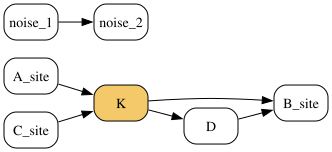

In [2]:
pkn_edges = [
    ("A_site", "K"),
    ("C_site", "K"),
    ("K", "B_site"),
    ("K", "D"),
    ("D", "B_site"),
    ("noise_1", "noise_2"),
]

pkn = Graph()
pkn.add_edges(pkn_edges)

pkn.plot(
    graph_attr={"rankdir": "LR"},
    node_attr={
        "fixedsize": "false",
        "shape": "box",
        "style": "rounded",
        "margin": "0.08,0.04",
    },
    custom_vertex_attr={
        "K": {"fillcolor": "#f3c969", "style": "rounded,filled"}
    },
)

PHONEMeS minimizes its objective, so the sign of each phosphosite score has a direct interpretation:

- a **negative score rewards** including the measured site;
- a **positive score penalizes** including it;
- a **zero score** marks a measured site as eligible without rewarding or penalizing it.

Here, `A_site` and `B_site` are supported by the data, whereas `C_site` is discouraged. The direct edge from `K` to `B_site` is deliberately made more expensive than the two-step alternative.

In [3]:
scores = {
    "A_site": -3.0,
    "C_site": 1.0,
    "B_site": -3.0,
}

method = BidirectionalPHONEMeS(anchor_policy="both")
problem = method.build(
    pkn,
    regulated_kinases=["K"],
    phosphosite_scores=scores,
    edge_costs={
        0: 0.2,
        1: 0.2,
        2: 2.0,
        3: 0.2,
        4: 0.2,
    },
)
problem.solve(solver="scipy")

Problem(Minimize(Expression(AFFINE, UNKNOWN, ())), [Inequality(Constant(CONSTANT, ZERO, (5, 1))), Inequality(Variable((5, 1), _dag_layer)), Inequality(Constant(CONSTANT, ZERO, (14, 2))), Inequality(Variable((14, 2), _flow)), Equality(Expression(AFFINE, UNKNOWN, (5, 2)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, NONNEGATIVE, (14, 2))), Equality(Expression(AFFINE, NONNEGATIVE, (14, 2)), Constant(CONSTANT, ZERO, ())), Equality(Expression(AFFINE, NONNEGATIVE, (14, 2)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, NONNEGATIVE, (14, 2))), Inequality(Variable((14, 2), _flow)), Inequality(Variable((5, 1), anchor_active_downstream, boolean=True)), Inequality(Variable((5, 1), anchor_active_upstream, boolean=True)), Inequality(Constant(CONSTANT, NONNEGATIVE, (5, 1))), Inequality(Constant(CONSTANT, NONNEGATIVE, (5, 1))), Inequality(Expression(AFFINE, NONNEGATIVE, (1, 1))), Inequality(Expression(AFFINE, UNKNOWN, (1, 1))), Inequality(Expression(AFFINE, NONNEGATIVE,

## Reading the inferred network

`edge_selected` is the complete biological network chosen for each condition. The directional arrays show whether an interaction is used to explain evidence upstream or downstream of an anchor. All of them use the normal biological PKN orientation, so upstream results do not need to be reversed.

In [4]:
upstream = problem.expr.edge_selected_upstream.value[:, 0] > 0.5
downstream = problem.expr.edge_selected_downstream.value[:, 0] > 0.5
selected = problem.expr.edge_selected.value[:, 0] > 0.5

# Retained biological interactions are stored first in processed_graph.
biological_edges = method.processed_graph.E[: selected.size]

def selected_interactions(mask):
    return [
        (next(iter(source)), next(iter(target)))
        for (source, target), keep in zip(biological_edges, mask)
        if keep
    ]

print("Upstream:", selected_interactions(upstream))
print("Downstream:", selected_interactions(downstream))
print("Combined:", selected_interactions(selected))

Upstream: [('A_site', 'K')]
Downstream: [('K', 'D'), ('D', 'B_site')]
Combined: [('A_site', 'K'), ('K', 'D'), ('D', 'B_site')]


The solution keeps the rewarded upstream site and excludes the penalized one. Downstream, it chooses the less expensive route through `D` instead of the costly direct interaction.

The following plot uses blue for upstream interactions, orange for downstream interactions, and purple if an interaction serves both roles.

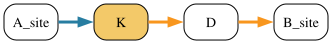

In [5]:
selected_indices = np.flatnonzero(selected)
inferred_network = method.processed_graph.edge_subgraph(selected_indices)

edge_style = {}
for displayed_index, original_index in enumerate(selected_indices):
    if upstream[original_index] and downstream[original_index]:
        color = "#7b2cbf"
    elif upstream[original_index]:
        color = "#277da1"
    else:
        color = "#f8961e"
    edge_style[displayed_index] = {"color": color, "penwidth": "3"}

inferred_network.plot(
    graph_attr={"rankdir": "LR"},
    node_attr={
        "fixedsize": "false",
        "shape": "box",
        "style": "rounded",
        "margin": "0.08,0.04",
    },
    custom_edge_attr=edge_style,
    custom_vertex_attr={
        "K": {"fillcolor": "#f3c969", "style": "rounded,filled"}
    },
)

## Choosing how anchors participate

The constructor's `anchor_policy` controls which side of every regulated kinase must be explained:

| Policy | Meaning |
| --- | --- |
| `"either"` | Require an upstream or downstream explanation; select both when supported. This is the default. |
| `"both"` | Require both an upstream and a downstream explanation. |
| `"downstream"` | Require the downstream side and make the upstream side optional. |

`"either"` is usually the safest choice for exploratory analysis because it does not force a weakly supported side into the network. Use `"both"` only when the experimental design requires two-sided explanations for every anchor.

## Multiple conditions

Use `build_many` with matching condition names. Each condition receives its own inferred network. Interaction costs apply to their union, so an interaction shared by several conditions is charged once.

In [6]:
many_method = BidirectionalPHONEMeS(anchor_policy="either")
many_problem = many_method.build_many(
    pkn,
    regulated_kinases={
        "control": ["K"],
        "treated": ["K"],
    },
    phosphosite_scores={
        "control": {"A_site": -3.0, "B_site": -2.0},
        "treated": {"C_site": -2.5, "B_site": -3.0},
    },
    edge_costs={0: 0.2, 1: 0.2, 2: 2.0, 3: 0.2, 4: 0.2},
)
many_problem.solve(solver="scipy")

print("Per-condition selection shape:", many_problem.expr.edge_selected.shape)
print("Union across conditions:", many_problem.expr.edge_selected_any.value > 0.5)

Per-condition selection shape: (5, 2)
Union across conditions: [ True  True False  True  True]


## Why this differs from original upside-down PHONEMeS

Original upside-down PHONEMeS solves a downstream problem and an upstream problem independently, then reports their union. That can be useful for exploration, but the final union is not itself an optimized solution.

`BidirectionalPHONEMeS` chooses both sides in one optimization. Consequently:

- a phosphosite contributes its score once even if it is relevant to both sides;
- an interaction cost is paid once when directions or conditions share it;
- upstream and downstream alternatives can be chosen jointly;
- acyclicity is checked on the complete network for each condition.

The method also uses exact connectivity pruning: it retains every interaction that can occur on a relevant directed path, rather than restricting candidates to shortest paths or a fixed path-length cutoff.

## Scores and edge costs in real analyses

Use `compute_phonemes_scores` as described in the [ordinary PHONEMeS guide](phonemes.ipynb) to calculate scores from p-values and optional fold changes. It accepts mappings, NumPy arrays, pandas Series, and pandas DataFrames for one or many conditions.

Pass interaction costs by original PKN edge index. Unspecified interactions use `default_edge_cost`. Negative costs reward an interaction, but selected interactions must still belong to an anchor-connected explanation.

`edge_costs` is global in `build_many` because PHONEMeS charges the cost of the combined network: if the same interaction is used in multiple conditions or directions, its cost is paid only once.

## Advanced: the general `Data` interface

Most users should prefer `build` or `build_many`. The general interface is available for workflows that already create CORNETO `Data` objects. It uses the vertex roles `regulated_kinase`, `phosphosite`, and `regulated_kinase_phosphosite`.

```python
from corneto import Data

data = Data.from_dict(
    {
        "tumour": {
            "features": [
                {
                    "id": "K",
                    "mapping": "vertex",
                    "role": "regulated_kinase",
                },
                {
                    "id": "B_site",
                    "mapping": "vertex",
                    "role": "phosphosite",
                    "value": -2.1,
                },
            ]
        }
    }
)

advanced_problem = BidirectionalPHONEMeS().build_from_data(pkn, data)
```

## Advanced: implementation in CORNETO

The details in this section are useful when extending the formulation or inspecting low-level results; they are not needed for ordinary analysis.

CORNETO first prepares exact upstream and downstream candidate regions. The optimization represents downstream paths in the PKN orientation and upstream paths through internal reversed copies of the same interactions. These internal copies are implementation details and are translated back to biological PKN orientation in every public edge-selection array.

| Variable | Meaning |
| --- | --- |
| `edge_selected_downstream` | Direction-specific downstream selections |
| `edge_selected_upstream` | Direction-specific upstream selections in biological orientation |
| `edge_selected` | Directional union for each condition |
| `edge_selected_any` | Union across conditions |
| `vertex_selected` | Vertices used in either direction |
| `anchor_active_downstream` | Anchors activated on the downstream side |
| `anchor_active_upstream` | Anchors activated on the upstream side |
| `flow_downstream` | Internal downstream connectivity values |
| `flow_upstream` | Internal upstream connectivity values |
| `dag_layer` | Per-condition order used to exclude cycles |

Auxiliary reversed and boundary interactions appear after the retained biological edges in `processed_graph`. They support the mathematical formulation but never appear in the biological edge-selection arrays or objective.